In [1]:
from socceraction.data.wyscout import PublicWyscoutLoader
import pandas as pd

print("Allt fungerar!")


Allt fungerar!


In [6]:
wyscout = PublicWyscoutLoader(
    root="../data/wyscout",
    download=True
)

In [3]:
import os

print(os.getcwd())

c:\Users\Användar\football-scout-ai\notebooks


In [4]:
from pathlib import Path

Path("../data/wyscout").mkdir(parents=True, exist_ok=True)

In [5]:
Path("../data/wyscout").exists()

True

In [7]:
competitions = wyscout.competitions()
competitions

,competition_id,season_id,country_name,competition_name,competition_gender,season_name
0,524,181248,Italy,Italian first division,male,2017/2018
1,364,181150,England,English first division,male,2017/2018
2,795,181144,Spain,Spanish first division,male,2017/2018
3,412,181189,France,French first division,male,2017/2018
4,426,181137,Germany,German first division,male,2017/2018
5,102,9291,International,European Championship,male,2016
6,28,10078,International,World Cup,male,2018


In [8]:
competitions = wyscout.competitions()
competitions

,competition_id,season_id,country_name,competition_name,competition_gender,season_name
0,524,181248,Italy,Italian first division,male,2017/2018
1,364,181150,England,English first division,male,2017/2018
2,795,181144,Spain,Spanish first division,male,2017/2018
3,412,181189,France,French first division,male,2017/2018
4,426,181137,Germany,German first division,male,2017/2018
5,102,9291,International,European Championship,male,2016
6,28,10078,International,World Cup,male,2018


In [9]:
competitions.columns


Index(['competition_id', 'season_id', 'country_name', 'competition_name',
       'competition_gender', 'season_name'],
      dtype='object')

In [10]:
games = wyscout.games(
    competition_id=364,
    season_id=181150
)

In [11]:
games.head()

,game_id,competition_id,season_id,game_date,game_day,home_team_id,away_team_id
0,2500089,364,181150,2018-05-13 14:00:00,38,1646,1659
1,2500090,364,181150,2018-05-13 14:00:00,38,1628,1627
2,2500091,364,181150,2018-05-13 14:00:00,38,1673,1609
3,2500092,364,181150,2018-05-13 14:00:00,38,1612,1651
4,2500093,364,181150,2018-05-13 14:00:00,38,1611,1644


In [12]:
len(games)

380

In [13]:
games[["game_id", "game_date", "home_team_id", "away_team_id",]].head()

,game_id,game_date,home_team_id,away_team_id
0,2500089,2018-05-13 14:00:00,1646,1659
1,2500090,2018-05-13 14:00:00,1628,1627
2,2500091,2018-05-13 14:00:00,1673,1609
3,2500092,2018-05-13 14:00:00,1612,1651
4,2500093,2018-05-13 14:00:00,1611,1644


In [14]:
game_id= games.iloc[0]["game_id"]
game_id

2500089

In [15]:
events = wyscout.events(game_id)
events.head()

,event_id,game_id,period_id,milliseconds,team_id,player_id,type_id,type_name,subtype_id,subtype_name,positions,tags
0,251700146,2500089,1,2763.597,1659,9637,8,Pass,85,Simple pass,"[{'y': 50, 'x': 50}, {'y': 45, 'x': 40}]",[{'id': 1801}]
1,251700147,2500089,1,4761.353,1659,8351,8,Pass,85,Simple pass,"[{'y': 45, 'x': 40}, {'y': 15, 'x': 39}]",[{'id': 1801}]
2,251700148,2500089,1,5533.097,1659,9285,8,Pass,85,Simple pass,"[{'y': 15, 'x': 39}, {'y': 30, 'x': 31}]",[{'id': 1801}]
3,251700161,2500089,1,7707.561,1659,239411,8,Pass,83,High pass,"[{'y': 30, 'x': 31}, {'y': 28, 'x': 66}]",[{'id': 1801}]
4,251700149,2500089,1,11614.943,1659,9637,8,Pass,85,Simple pass,"[{'y': 28, 'x': 66}, {'y': 18, 'x': 71}]",[{'id': 1801}]


In [16]:
events.columns

Index(['event_id', 'game_id', 'period_id', 'milliseconds', 'team_id',
       'player_id', 'type_id', 'type_name', 'subtype_id', 'subtype_name',
       'positions', 'tags'],
      dtype='object')

In [17]:
events["type_name"].value_counts()

type_name
Pass                       800
Duel                       412
Others on the ball         118
Free Kick                  102
Interruption                75
Foul                        23
Shot                        23
Save attempt                 9
Goalkeeper leaving line      6
Offside                      4
Name: count, dtype: int64

In [18]:
shots = events[events["type_name"] == "Shot"]
shots.head()

,event_id,game_id,period_id,milliseconds,team_id,player_id,type_id,type_name,subtype_id,subtype_name,positions,tags
367,251700604,2500089,1,1239333.857,1659,245813,10,Shot,100,Shot,"[{'y': 61, 'x': 88}, {'y': 100, 'x': 100}]","[{'id': 402}, {'id': 201}, {'id': 1201}, {'id'..."
409,251700478,2500089,1,1324245.616,1646,8980,10,Shot,100,Shot,"[{'y': 38, 'x': 78}, {'y': 0, 'x': 0}]","[{'id': 402}, {'id': 201}, {'id': 1203}, {'id'..."
462,251700689,2500089,1,1494384.387,1659,9285,10,Shot,100,Shot,"[{'y': 29, 'x': 87}, {'y': 100, 'x': 100}]","[{'id': 401}, {'id': 201}, {'id': 1203}, {'id'..."
469,251700693,2500089,1,1523716.107,1659,8351,10,Shot,100,Shot,"[{'y': 50, 'x': 77}, {'y': 100, 'x': 100}]","[{'id': 401}, {'id': 2101}, {'id': 1802}]"
503,251700755,2500089,1,1651208.686,1659,9637,10,Shot,100,Shot,"[{'y': 83, 'x': 89}, {'y': 100, 'x': 100}]","[{'id': 402}, {'id': 201}, {'id': 1214}, {'id'..."


In [19]:
shots[["event_id", "team_id", "player_id", "period_id", "milliseconds",
     "subtype_name", "positions", "tags"]].head(10)

,event_id,team_id,player_id,period_id,milliseconds,subtype_name,positions,tags
367,251700604,1659,245813,1,1239333.857,Shot,"[{'y': 61, 'x': 88}, {'y': 100, 'x': 100}]","[{'id': 402}, {'id': 201}, {'id': 1201}, {'id'..."
409,251700478,1646,8980,1,1324245.616,Shot,"[{'y': 38, 'x': 78}, {'y': 0, 'x': 0}]","[{'id': 402}, {'id': 201}, {'id': 1203}, {'id'..."
462,251700689,1659,9285,1,1494384.387,Shot,"[{'y': 29, 'x': 87}, {'y': 100, 'x': 100}]","[{'id': 401}, {'id': 201}, {'id': 1203}, {'id'..."
469,251700693,1659,8351,1,1523716.107,Shot,"[{'y': 50, 'x': 77}, {'y': 100, 'x': 100}]","[{'id': 401}, {'id': 2101}, {'id': 1802}]"
503,251700755,1659,9637,1,1651208.686,Shot,"[{'y': 83, 'x': 89}, {'y': 100, 'x': 100}]","[{'id': 402}, {'id': 201}, {'id': 1214}, {'id'..."
517,251700687,1646,8125,1,1717474.290,Shot,"[{'y': 51, 'x': 78}, {'y': 0, 'x': 0}]","[{'id': 402}, {'id': 201}, {'id': 1212}, {'id'..."
693,251700841,1646,8925,1,2306063.575,Shot,"[{'y': 47, 'x': 90}, {'y': 0, 'x': 0}]","[{'id': 301}, {'id': 402}, {'id': 2101}, {'id'..."
694,251700843,1646,9206,1,2307083.625,Shot,"[{'y': 49, 'x': 92}, {'y': 0, 'x': 0}]","[{'id': 101}, {'id': 401}, {'id': 1401}, {'id'..."
705,251700970,1659,9637,1,2434522.184,Shot,"[{'y': 43, 'x': 90}, {'y': 100, 'x': 100}]","[{'id': 403}, {'id': 201}, {'id': 1212}, {'id'..."
756,251700903,1646,9433,1,2698590.015,Shot,"[{'y': 67, 'x': 92}, {'y': 0, 'x': 0}]","[{'id': 403}, {'id': 201}, {'id': 1207}, {'id'..."


In [20]:
teams = wyscout.teams(game_id)
teams

,team_id,team_name_short,team_name
0,1646,Burnley,Burnley FC
1,1659,AFC Bournemouth,AFC Bournemouth


In [21]:
players = wyscout.players(game_id)
players.head()

,player_id,nickname,firstname,lastname,birth_date,player_name,team_id,jersey_number,minutes_played,is_starter,game_id
0,9206,C. Wood,Chris,Wood,1991-12-07,Chris Wood,1646,0,62,True,2500089
1,93,J. Guðmunds­son,Johann,Berg Guðmunds­son,1990-10-27,Johann Berg Guðmunds­son,1646,0,81,True,2500089
2,10108,K. Long,Kevin,Long,1990-08-18,Kevin Long,1646,0,96,True,2500089
3,8433,S. Ward,Stephen,Ward,1985-08-20,Stephen Ward,1646,0,96,True,2500089
4,8125,J. Cork,Jack,Cork,1989-06-25,Jack Cork,1646,0,96,True,2500089


In [ ]:
shots = events[events["type_name"] == ]

In [22]:
shots[["team_id", "player_id", "positions", "tags"]].head(10)

,team_id,player_id,positions,tags
367,1659,245813,"[{'y': 61, 'x': 88}, {'y': 100, 'x': 100}]","[{'id': 402}, {'id': 201}, {'id': 1201}, {'id'..."
409,1646,8980,"[{'y': 38, 'x': 78}, {'y': 0, 'x': 0}]","[{'id': 402}, {'id': 201}, {'id': 1203}, {'id'..."
462,1659,9285,"[{'y': 29, 'x': 87}, {'y': 100, 'x': 100}]","[{'id': 401}, {'id': 201}, {'id': 1203}, {'id'..."
469,1659,8351,"[{'y': 50, 'x': 77}, {'y': 100, 'x': 100}]","[{'id': 401}, {'id': 2101}, {'id': 1802}]"
503,1659,9637,"[{'y': 83, 'x': 89}, {'y': 100, 'x': 100}]","[{'id': 402}, {'id': 201}, {'id': 1214}, {'id'..."
517,1646,8125,"[{'y': 51, 'x': 78}, {'y': 0, 'x': 0}]","[{'id': 402}, {'id': 201}, {'id': 1212}, {'id'..."
693,1646,8925,"[{'y': 47, 'x': 90}, {'y': 0, 'x': 0}]","[{'id': 301}, {'id': 402}, {'id': 2101}, {'id'..."
694,1646,9206,"[{'y': 49, 'x': 92}, {'y': 0, 'x': 0}]","[{'id': 101}, {'id': 401}, {'id': 1401}, {'id'..."
705,1659,9637,"[{'y': 43, 'x': 90}, {'y': 100, 'x': 100}]","[{'id': 403}, {'id': 201}, {'id': 1212}, {'id'..."
756,1646,9433,"[{'y': 67, 'x': 92}, {'y': 0, 'x': 0}]","[{'id': 403}, {'id': 201}, {'id': 1207}, {'id'..."


In [23]:
shots = shots.copy()

shots["x"] = shots["positions"].apply(lambda pos: pos[0]["x"])
shots["y"] = shots["positions"].apply(lambda pos: pos[0]["y"])

In [24]:
shots[["team_id", "player_id", "x", "y"]].head(10)

,team_id,player_id,x,y
367,1659,245813,88,61
409,1646,8980,78,38
462,1659,9285,87,29
469,1659,8351,77,50
503,1659,9637,89,83
517,1646,8125,78,51
693,1646,8925,90,47
694,1646,9206,92,49
705,1659,9637,90,43
756,1646,9433,92,67


In [25]:
shots = shots.copy()

shots["start_x"] = shots["positions"].apply(lambda pos: pos[0]["x"])
shots["start_y"] = shots["positions"].apply(lambda pos: pos[0]["y"])

shots["end_x"] = shots["positions"].apply(lambda pos: pos[1]["x"])
shots["end_y"] = shots["positions"].apply(lambda pos: pos[1]["y"])

In [26]:
shots[
    ["team_id", "player_id", "start_x", "start_y", "end_x", "end_y"]
].head(10)

,team_id,player_id,start_x,start_y,end_x,end_y
367,1659,245813,88,61,100,100
409,1646,8980,78,38,0,0
462,1659,9285,87,29,100,100
469,1659,8351,77,50,100,100
503,1659,9637,89,83,100,100
517,1646,8125,78,51,0,0
693,1646,8925,90,47,0,0
694,1646,9206,92,49,0,0
705,1659,9637,90,43,100,100
756,1646,9433,92,67,0,0


In [27]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt

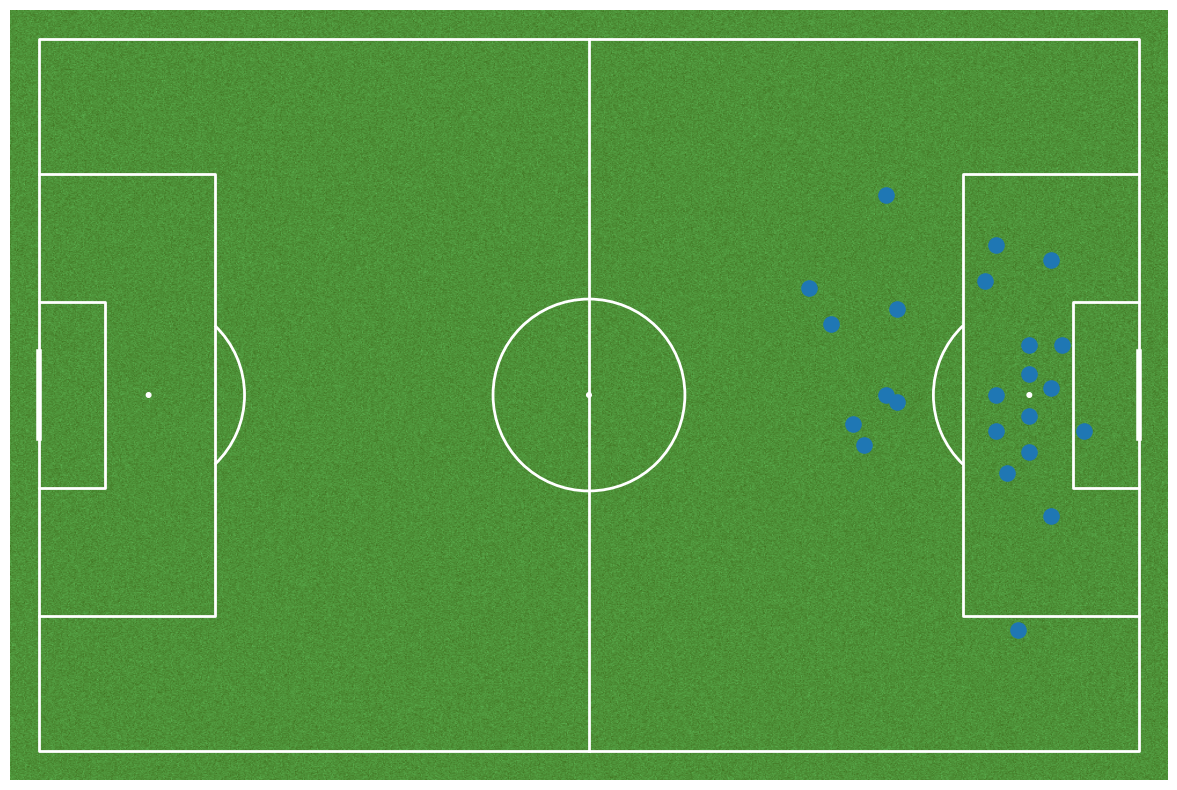

In [28]:
pitch = Pitch(
    pitch_type="wyscout",
    pitch_color="grass",
    line_color="white"
)

fig, ax = pitch.draw(figsize=(12, 8))

pitch.scatter(
    shots["start_x"],
    shots["start_y"],
    ax=ax,
    s=120
)

plt.show()

In [29]:
shots["team_id"].value_counts()

team_id
1659    14
1646     9
Name: count, dtype: int64

In [33]:
shots[["player_id", "team_id", "start_x", "start_y", "tags"]].head(10)

,player_id,team_id,start_x,start_y,tags
367,245813,1659,88,61,"[{'id': 402}, {'id': 201}, {'id': 1201}, {'id'..."
409,8980,1646,78,38,"[{'id': 402}, {'id': 201}, {'id': 1203}, {'id'..."
462,9285,1659,87,29,"[{'id': 401}, {'id': 201}, {'id': 1203}, {'id'..."
469,8351,1659,77,50,"[{'id': 401}, {'id': 2101}, {'id': 1802}]"
503,9637,1659,89,83,"[{'id': 402}, {'id': 201}, {'id': 1214}, {'id'..."
517,8125,1646,78,51,"[{'id': 402}, {'id': 201}, {'id': 1212}, {'id'..."
693,8925,1646,90,47,"[{'id': 301}, {'id': 402}, {'id': 2101}, {'id'..."
694,9206,1646,92,49,"[{'id': 101}, {'id': 401}, {'id': 1401}, {'id'..."
705,9637,1659,90,43,"[{'id': 403}, {'id': 201}, {'id': 1212}, {'id'..."
756,9433,1646,92,67,"[{'id': 403}, {'id': 201}, {'id': 1207}, {'id'..."


In [34]:
shots.iloc[0]["tags"]

[{'id': 402}, {'id': 201}, {'id': 1201}, {'id': 1801}]

In [35]:
def is_goal(tags):
    return any(tag["id"] == 101 for tag in tags)

shots["is_goal"] = shots["tags"].apply(is_goal)

In [36]:
shots[["player_id", "start_x", "start_y", "is_goal"]]

,player_id,start_x,start_y,is_goal
367,245813,88,61,False
409,8980,78,38,False
462,9285,87,29,False
469,8351,77,50,False
503,9637,89,83,False
517,8125,78,51,False
693,8925,90,47,False
694,9206,92,49,True
705,9637,90,43,False
756,9433,92,67,False


In [37]:
shots["is_goal"].value_counts()

is_goal
False    20
True      3
Name: count, dtype: int64

In [38]:
all_shots_list = []

for game_id in games["game_id"]:
    game_events = wyscout.events(game_id)

    game_shots = game_events[
        game_events["type_name"] == "Shot"
    ].copy()

    game_shots["game_id"] = game_id

    all_shots_list.append(game_shots)

all_shots = pd.concat(all_shots_list, ignore_index=True)

In [40]:
len(all_shots)
all_shots.head()

,event_id,game_id,period_id,milliseconds,team_id,player_id,type_id,type_name,subtype_id,subtype_name,positions,tags
0,251700604,2500089,1,1239333.857,1659,245813,10,Shot,100,Shot,"[{'y': 61, 'x': 88}, {'y': 100, 'x': 100}]","[{'id': 402}, {'id': 201}, {'id': 1201}, {'id'..."
1,251700478,2500089,1,1324245.616,1646,8980,10,Shot,100,Shot,"[{'y': 38, 'x': 78}, {'y': 0, 'x': 0}]","[{'id': 402}, {'id': 201}, {'id': 1203}, {'id'..."
2,251700689,2500089,1,1494384.387,1659,9285,10,Shot,100,Shot,"[{'y': 29, 'x': 87}, {'y': 100, 'x': 100}]","[{'id': 401}, {'id': 201}, {'id': 1203}, {'id'..."
3,251700693,2500089,1,1523716.107,1659,8351,10,Shot,100,Shot,"[{'y': 50, 'x': 77}, {'y': 100, 'x': 100}]","[{'id': 401}, {'id': 2101}, {'id': 1802}]"
4,251700755,2500089,1,1651208.686,1659,9637,10,Shot,100,Shot,"[{'y': 83, 'x': 89}, {'y': 100, 'x': 100}]","[{'id': 402}, {'id': 201}, {'id': 1214}, {'id'..."


In [41]:
all_shots["start_x"] = all_shots["positions"].apply(
    lambda pos: pos[0]["x"]
)

all_shots["start_y"] = all_shots["positions"].apply(
    lambda pos: pos[0]["y"]
)

all_shots["end_x"] = all_shots["positions"].apply(
    lambda pos: pos[1]["x"]
)

all_shots["end_y"] = all_shots["positions"].apply(
    lambda pos: pos[1]["y"]
)

In [42]:
all_shots["is_goal"] = all_shots["tags"].apply(
    lambda tags: any(tag["id"] == 101 for tag in tags)
)

In [43]:
all_shots[
    [
        "game_id",
        "team_id",
        "player_id",
        "start_x",
        "start_y",
        "end_x",
        "end_y",
        "is_goal"
    ]
].head(10)

,game_id,team_id,player_id,start_x,start_y,end_x,end_y,is_goal
0,2500089,1659,245813,88,61,100,100,False
1,2500089,1646,8980,78,38,0,0,False
2,2500089,1659,9285,87,29,100,100,False
3,2500089,1659,8351,77,50,100,100,False
4,2500089,1659,9637,89,83,100,100,False
5,2500089,1646,8125,78,51,0,0,False
6,2500089,1646,8925,90,47,0,0,False
7,2500089,1646,9206,92,49,0,0,True
8,2500089,1659,9637,90,43,100,100,False
9,2500089,1646,9433,92,67,0,0,False


In [44]:
all_shots["is_goal"].value_counts()

is_goal
False    7537
True      914
Name: count, dtype: int64

In [45]:
len(all_shots)

8451

In [46]:
import numpy as np

all_shots["distance_to_goal"] = np.sqrt(
    (100 - all_shots["start_x"])**2 +
    (50 - all_shots["start_y"])**2
)

In [47]:
all_shots[
    ["start_x", "start_y", "distance_to_goal", "is_goal"]
].head(10)

,start_x,start_y,distance_to_goal,is_goal
0,88,61,16.278821,False
1,78,38,25.059928,False
2,87,29,24.698178,False
3,77,50,23.000000,False
4,89,83,34.785054,False
5,78,51,22.022716,False
6,90,47,10.440307,False
7,92,49,8.062258,True
8,90,43,12.206556,False
9,92,67,18.788294,False


In [48]:
all_shots.groupby("is_goal")["distance_to_goal"].mean()

is_goal
False    20.667112
True     13.250218
Name: distance_to_goal, dtype: float64

In [49]:
all_shots["x_m"] = all_shots["start_x"] / 100 * 105
all_shots["y_m"] = all_shots["start_y"] / 100 * 68

In [50]:
all_shots["distance_m"] = np.sqrt(
    (105 - all_shots["x_m"])**2 +
    (34 - all_shots["y_m"])**2
)

In [51]:
goal_y1 = 34 - 7.32 / 2
goal_y2 = 34 + 7.32 / 2

dx = 105 - all_shots["x_m"]

angle1 = np.arctan2(goal_y1 - all_shots["y_m"], dx)
angle2 = np.arctan2(goal_y2 - all_shots["y_m"], dx)

all_shots["angle"] = np.abs(angle2 - angle1)

In [52]:
all_shots["angle_degrees"] = np.degrees(all_shots["angle"])


In [53]:
all_shots[
    ["start_x", "start_y", "distance_m", "angle_degrees", "is_goal"]
].head(10)

,start_x,start_y,distance_m,angle_degrees,is_goal
0,88,61,14.653000,24.614795,False
1,78,38,24.498890,16.074839,False
2,87,29,19.754516,14.849898,False
3,77,50,24.150000,17.235513,False
4,89,83,25.237989,7.721413,False
5,78,51,23.110006,17.991425,False
6,90,47,10.696336,37.266402,False
7,92,49,8.427479,46.856638,True
8,90,43,11.528556,32.745693,False
9,92,67,14.289633,17.862446,False


In [56]:
all_shots.groupby("is_goal")[
    ["distance_m", "angle_degrees"]
].mean()


,distance_m,angle_degrees
is_goal,,
False,19.038983,22.567833
True,12.053187,38.583183


In [57]:
def get_body_part(tags):
    tag_ids = [tag["id"] for tag in tags]

    if 401 in tag_ids:
        return "left_foot"
    elif 402 in tag_ids:
        return "right_foot"
    elif 403 in tag_ids:
        return "head_or_other"
    else:
        return "unknown"

In [58]:
all_shots["body_part"] = all_shots["tags"].apply(get_body_part)

In [59]:
all_shots["body_part"].value_counts()

body_part
right_foot       4349
left_foot        2785
head_or_other    1317
Name: count, dtype: int64

In [60]:
all_shots.groupby("body_part")["is_goal"].agg(
    shots="count",
    goals="sum",
    goal_rate="mean"
)

,shots,goals,goal_rate
body_part,,,
head_or_other,1317,178,0.135156
left_foot,2785,293,0.105206
right_foot,4349,443,0.101862


In [61]:
all_shots.groupby("body_part")["is_goal"].agg(
    shots="count",
    goals="sum",
    goal_rate="mean"
)

,shots,goals,goal_rate
body_part,,,
head_or_other,1317,178,0.135156
left_foot,2785,293,0.105206
right_foot,4349,443,0.101862


In [62]:
X = all_shots[
    ["distance_m", "angle_degrees", "body_part"]
]

In [63]:
y = all_shots["is_goal"].astype(int)

In [64]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [66]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

preprocessor = ColumnTransformer(
    transformers=[
        (
            "body_part",
            OneHotEncoder(handle_unknown="ignore"),
            ["body_part"]
        )
    ],
    remainder="passthrough"
)

xg_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

In [67]:
xg_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int32](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](3,)","['distance_m','angle_degrees','body_part']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,3
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('body_part', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specifie

In [68]:
xg_predictions = xg_model.predict_proba(X_test)[:, 1]

,distance_m,angle_degrees,body_part,actual_goal,xG
824,27.716105,13.181603,right_foot,0,0.023440
5955,18.310350,22.094316,right_foot,0,0.080365
2088,12.153370,29.780923,right_foot,0,0.175716
7230,34.306594,10.478925,right_foot,0,0.010484
6479,24.302693,17.027457,left_foot,0,0.035880
6064,26.349565,11.485173,right_foot,0,0.026187
1149,15.923078,24.135825,right_foot,0,0.107659
5004,20.618012,12.627119,right_foot,0,0.050463
3971,26.250000,15.874994,right_foot,0,0.029429
2078,28.963427,13.103538,right_foot,0,0.020360


In [70]:
from sklearn.metrics import (
    log_loss,
    brier_score_loss,
    roc_auc_score
)

print("Log Loss:", log_loss(y_test, xg_predictions))
print("Brier Score:", brier_score_loss(y_test, xg_predictions))
print("ROC-AUC:", roc_auc_score(y_test, xg_predictions))

Log Loss: 0.2993479912567955
Brier Score: 0.08645153316055568
ROC-AUC: 0.753996898146135


In [71]:
import numpy as np

baseline_probability = y_train.mean()

baseline_predictions = np.full(
    len(y_test),
    baseline_probability
)

print("Baseline probability:", baseline_probability)
print(
    "Baseline Brier:",
    brier_score_loss(y_test, baseline_predictions)
)
print(
    "Our model Brier:",
    brier_score_loss(y_test, xg_predictions)
)

Baseline probability: 0.10813609467455622
Baseline Brier: 0.09650842937070316
Our model Brier: 0.08645153316055568


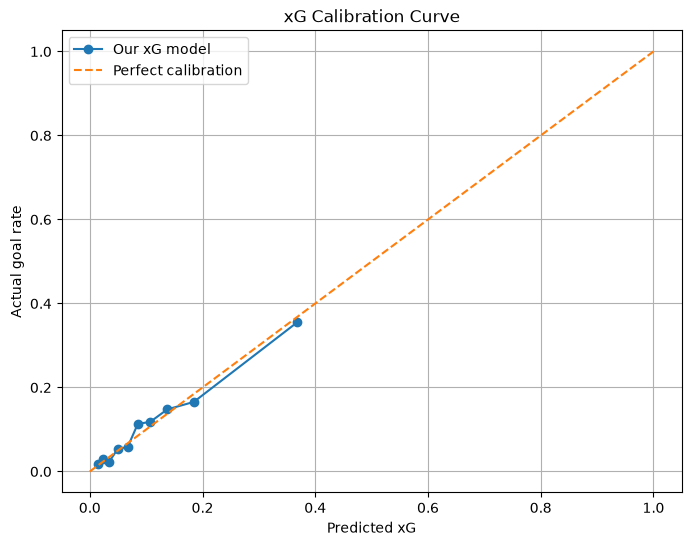

In [72]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(
    y_test,
    xg_predictions,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(8, 6))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="Our xG model"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel("Predicted xG")
plt.ylabel("Actual goal rate")
plt.title("xG Calibration Curve")
plt.legend()
plt.grid()

plt.show()

In [73]:
all_shots["xG"] = xg_model.predict_proba(
    all_shots[["distance_m", "angle_degrees", "body_part"]]
)[:, 1]

In [74]:
all_shots[
    [
        "game_id",
        "team_id",
        "player_id",
        "start_x",
        "start_y",
        "is_goal",
        "xG"
    ]
].head(10)

,game_id,team_id,player_id,start_x,start_y,is_goal,xG
0,2500089,1659,245813,88,61,False,0.123647
1,2500089,1646,8980,78,38,False,0.035865
2,2500089,1659,9285,87,29,False,0.055891
3,2500089,1659,8351,77,50,False,0.036668
4,2500089,1659,9637,89,83,False,0.027053
5,2500089,1646,8125,78,51,False,0.043698
6,2500089,1646,8925,90,47,False,0.232493
7,2500089,1646,9206,92,49,True,0.322165
8,2500089,1659,9637,90,43,False,0.088296
9,2500089,1646,9433,92,67,False,0.046631


In [75]:
player_stats = (
    all_shots
    .groupby("player_id")
    .agg(
        shots=("event_id", "count"),
        goals=("is_goal", "sum"),
        xG=("xG", "sum")
    )
    .reset_index()
)

player_stats["goals_minus_xG"] = (
    player_stats["goals"] - player_stats["xG"]
)

In [76]:
player_stats.sort_values(
    "xG",
    ascending=False
).head(20)

,player_id,shots,goals,xG,goals_minus_xG
160,8717,162,27,22.139763,4.860237
334,120353,136,31,16.802196,14.197804
204,11066,79,17,14.219501,2.780499
64,7905,76,16,13.169247,2.830753
127,8325,86,17,12.805931,4.194069
214,14703,67,11,10.505254,0.494746
28,3324,74,11,10.453276,0.546724
402,340386,53,13,10.343321,2.656679
411,377071,90,5,10.339201,-5.339201
248,25413,63,12,10.186696,1.813304


In [77]:
players = wyscout.players()

players.head()

TypeError: PublicWyscoutLoader.players() missing 1 required positional argument: 'game_id'

In [78]:
game_id = games.iloc[0]["game_id"]

players_test = wyscout.players(game_id)
players_test.head()

,player_id,nickname,firstname,lastname,birth_date,player_name,team_id,jersey_number,minutes_played,is_starter,game_id
0,9206,C. Wood,Chris,Wood,1991-12-07,Chris Wood,1646,0,62,True,2500089
1,93,J. Guðmunds­son,Johann,Berg Guðmunds­son,1990-10-27,Johann Berg Guðmunds­son,1646,0,81,True,2500089
2,10108,K. Long,Kevin,Long,1990-08-18,Kevin Long,1646,0,96,True,2500089
3,8433,S. Ward,Stephen,Ward,1985-08-20,Stephen Ward,1646,0,96,True,2500089
4,8125,J. Cork,Jack,Cork,1989-06-25,Jack Cork,1646,0,96,True,2500089


In [79]:
players_test.columns

Index(['player_id', 'nickname', 'firstname', 'lastname', 'birth_date',
       'player_name', 'team_id', 'jersey_number', 'minutes_played',
       'is_starter', 'game_id'],
      dtype='object')

In [81]:
all_players_list = []

for game_id in games["game_id"]:
    game_players = wyscout.players(game_id)
    all_players_list.append(game_players)

all_players = pd.concat(
    all_players_list,
    ignore_index=True
)

In [82]:
player_info = (
    all_players[
        ["player_id", "player_name"]
    ]
    .drop_duplicates(subset="player_id")
)

In [83]:
len(player_info)

515

In [84]:
player_stats_named = player_stats.merge(
    player_info,
    on="player_id",
    how="left"
)

In [85]:
player_stats_named["player_name"].isna().sum()

1

In [86]:
player_stats_named[
    player_stats_named["player_name"].isna()
]

,player_id,shots,goals,xG,goals_minus_xG,player_name
0,0,1,0,0.062942,-0.062942,NaN


In [87]:
print("Före merge:", len(player_stats))
print("Efter merge:", len(player_stats_named))

Före merge: 426
Efter merge: 426


In [91]:
player_stats_named[
    ["player_name", "shots", "goals", "xG", "goals_minus_xG"]
].sort_values(
    "xG",
    ascending=False
).head(20)

,player_name,shots,goals,xG,goals_minus_xG
160,Harry Kane,162,27,22.139763,4.860237
334,Mohamed Salah Ghaly,136,31,16.802196,14.197804
204,Raheem Shaquille Sterling,79,17,14.219501,2.780499
64,Romelu Lukaku Menama,76,16,13.169247,2.830753
127,Sergio Leonel Agüero del Castillo,86,17,12.805931,4.194069
214,Marko Arnautović,67,11,10.505254,0.494746
28,Álvaro Borja Morata Martín,74,11,10.453276,0.546724
402,Gabriel Fernando de Jesus,53,13,10.343321,2.656679
411,Richarlison de Andrade,90,5,10.339201,-5.339201
248,Alexandre Lacazette,63,12,10.186696,1.813304


In [90]:
player_stats_named = player_stats_named[
    player_stats_named["player_id"] != 0
]